<a href="https://colab.research.google.com/github/MarceleLouiseSAra/machineLearningStudies/blob/development/redeNeuralComPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
rede = tf.keras.models.Sequential()

Camadas "densas" estão conectadas àquilo o que vem antes delas.

In [3]:
rede.add(tf.keras.layers.Dense( # primeira camada
    units = 10, # dez neurônios
    input_shape = (4,), # cada neurônio tem quatro entradas
    activation = 'sigmoid' # função de ativação: sigmóide
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
rede.add(tf.keras.layers.Dense( # Segunda camada
    units = 16,
    activation = 'sigmoid'
    )
)

Abstrai-se o número de entradas da segunda camada porque subtenden-se que o número de entradas é o número de saídas da camada anterior: número de saídas = número de neurônios = 10;

In [5]:
rede.add(tf.keras.layers.Dense(
    units = 3, # três possíveis flores
    activation = 'softmax' # para que a soma das trễs entradas seja sempre menor ou igual a um
  )
)

Como a rede aprende? O que são boas respostas? O quão longe está a resposta contínua da resposta certa? Quais pesos e viéses minimizam o erro?

A relação entre o erro total da rede (*mínimos locais) e a combinação de pesos e vieses resulta em uma função custo/objetivo/de perda, ou "função de erro total da rede". Há diferentes funções de perda, pois há diferentes formas de se calcular *distância*.

In [6]:
rede.compile( # especifica como a rede deve aprender
    loss = 'sparse_categorical_crossentropy', # função de erro
    optimizer = 'adam', # minimizador de erro
    metrics = ['accuracy'] # a resposta correta é aquela cuja maior probabilidade gerada está associada à resposta esperada
)

In [7]:
from sklearn.datasets import load_iris

In [8]:
banco = load_iris()

In [9]:
banco.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [10]:
banco['data'][37]

array([4.9, 3.6, 1.4, 0.1])

In [11]:
banco['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [12]:
banco['target'][37]

np.int64(0)

In [13]:
banco['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

A flor 37 é uma setosa.

In [14]:
x = banco['data'] # perguntas
y = banco['target'] # respostas

Divide-se o banco em dois blocos: uma lista de exercícios, com consulta, e um teste, sem consulta.

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2 # 20% das perguntas estão reservadas para o teste, enquanto 80% serão utilizadas no treinamento
)

In [17]:
rede.evaluate(x_test, y_test) # realizando o teste sem treinamento

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.1667 - loss: 1.4642


[1.4642261266708374, 0.1666666716337204]

In [18]:
modelo_treinado = rede.fit(
    x_train,
    y_train,
    epochs = 150, # quantas vezes a rede treina
    validation_data = (x_test, y_test)
  )

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3750 - loss: 1.2117 - val_accuracy: 0.1667 - val_loss: 1.4220
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3750 - loss: 1.1939 - val_accuracy: 0.1667 - val_loss: 1.3795
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3750 - loss: 1.1723 - val_accuracy: 0.1667 - val_loss: 1.3435
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3750 - loss: 1.1580 - val_accuracy: 0.1667 - val_loss: 1.3099
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3750 - loss: 1.1433 - val_accuracy: 0.1667 - val_loss: 1.2805
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3750 - loss: 1.1316 - val_accuracy: 0.1667 - val_loss: 1.2543
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3750 - loss: 1.1239 - val_accuracy: 0.1667 - val_loss: 1.2305
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3750 - loss: 1.1147 - val_accuracy: 0.1667 - val_loss:

In [19]:
import matplotlib.pyplot as plt

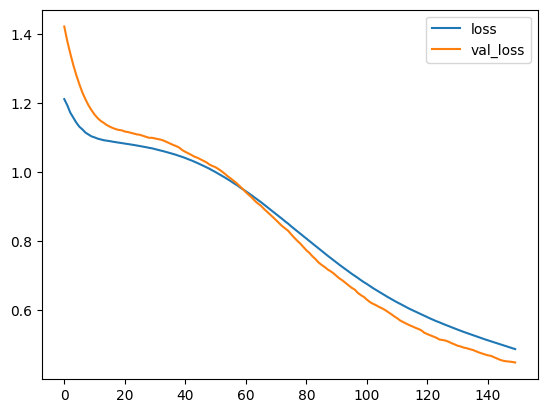

In [23]:
plt.plot(modelo_treinado.history['loss'], label = 'loss')
plt.plot(modelo_treinado.history['val_loss'], label = 'val_loss')
plt.legend()

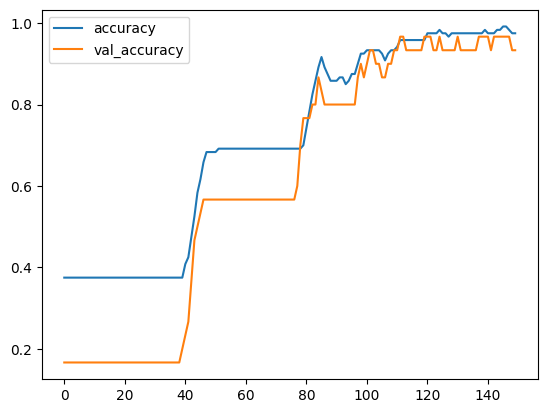

In [24]:
plt.plot(modelo_treinado.history['accuracy'], label = 'accuracy')
plt.plot(modelo_treinado.history['val_accuracy'], label = 'val_accuracy')
plt.legend()

In [25]:
import numpy as np

In [26]:
rede.predict(np.array(
    [[5.4, 2.5, 3.7, 1.0]]
  )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


array([[0.15573055, 0.5566144 , 0.28765506]], dtype=float32)

Provavelmente, trata-se de uma versicolor.